#Instructions: Run all the sections in succession. If you have new files you are wishing to test, click the sideways carrot next to Section 2 to see hidden cells and directions.

# Section 1: Importing Libraries

In [ ]:
# Install necessary libraries
!pip install gspread pandas

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import gspread
from google.auth import default
from google.colab import drive

# Section 2: Importing Test Files into ```dataframes``` Variable

In [ ]:
# 1) The true Spreadsheet ID (from the /d/.../edit URL)
SPREADSHEET_ID = '12shIbyySk8HSyqtIJMOkD1fRMGyxbb7jAwNDowP9CBA'

# 2) GIDs for each tab you want
#sheet_gids = ['569122249'] #['569122249', '469203121', '914584687'], 6.4
#sheet_gids = ['?'] #['0', '288802849', '1389948408'] #5V
#sheet_gids = ['?'] #['1089125397', '1386570843', '256067322'] #4V
#sheet_gids = ['?'] #['512978390', '802400971', '1417200143'] #3V
#sheet_gids = ['?'] #['1388987897', '1115094444', '1670832268'] #2V
#sheet_gids = ['2137190421'] #['2137190421'] # 5V-noFb
#sheet_gids = ['?'] #['2059071296'] # 3V-noFb
#sheet_gids = ['?'] #['1369235071'] # 2V-noFb
#sheet_gids = ['1472807806'] #https://docs.google.com/spreadsheets/d/1I3W6j7jK28liYQFnFK8MHH_tyNvLYMvS1_kJGZaubEA/export?format=csv&gid=1472807806
sheet_gids = ['128794124'] #['1280478417'] #['955837113'] # 4V-noFb

# Under damped: 1280478417, 1483843893, 128794124, Critically damped: 914584687 Over damped: 569122249, 469203121

# 3) URL template
EXPORT_URL = (
    'https://docs.google.com/spreadsheets/d/'
    f'{SPREADSHEET_ID}'
    '/export?format=csv&gid={}'
)

dataframes = {}
for gid in sheet_gids:
    url = EXPORT_URL.format(gid)
    print("Fetching:", url)        # ← Test this in your browser first!
    try:
        df = pd.read_csv(url, dtype=str)
        dataframes[gid] = df
        print(f"  → Loaded sheet {gid}, shape={df.shape}")
    except Exception as e:
        print(f"  ✗ Failed to load gid={gid}: {e}")

Fetching: https://docs.google.com/spreadsheets/d/12shIbyySk8HSyqtIJMOkD1fRMGyxbb7jAwNDowP9CBA/export?format=csv&gid=128794124
  → Loaded sheet 128794124, shape=(5390, 38)


# Section 3: Data Processing

In [ ]:
# # Global Variables 6.4V SEMAYAT's critically damped T1
# G_PROMINENCE = 0.3 # minimuum vertical (y) value prominence between peaks
# G_DISTANCE = 120 # minimum detectable distance between peaks
# G_AXIS = 'Roll'
# SECOND_PEAK = 193 # random peak to add if not enough peaks
# GNUM = 0 # Giannah number is the number of skipped data points from the beginning of the graph
# VERTOFFSET = 0 # vertical offset for high damping graphs (remains 0 for low damping graphs)
# G_VIEW = 400 # number of data points to view after the starting index (default is 600)
# GPROCESS = GNUM # Giannah process is the numver of skipped data points from beginning of process_euler() function

In [ ]:
# #Global Variables # OVER DAMPED - KYLE
# G_PROMINENCE = 0.2 # minimuum vertical (y) value prominence between peaks
# G_DISTANCE = 100 # minimum detectable distance between peaks
# G_AXIS = 'Roll'
# SECOND_PEAK = 725 # random peak to add if not enough peaks
# GNUM = 110 # Giannah number is the number of skipped data points from the beginning of the graph
# VERTOFFSET = 4 # vertical offset for high damping graphs (remains 0 for low damping graphs)
# G_VIEW = 750 # number of data points to view after the starting index (default is 600)
# GPROCESS = GNUM # Giannah process is the numver of skipped data points from beginning of process_euler() function

In [ ]:
# #Global Variables # CRITICALLY DAMPED - KYLE
# G_PROMINENCE = 0.1 # minimuum vertical (y) value prominence between peaks
# G_DISTANCE = 100 # minimum detectable distance between peaks
# G_AXIS = 'Roll'
# SECOND_PEAK = 315 # random peak to add if not enough peaks
# GNUM = 75 # Giannah number is the number of skipped data points from the beginning of the graph
# VERTOFFSET = 0 # vertical offset for high damping graphs (remains 0 for low damping graphs)
# G_VIEW = 900 # number of data points to view after the starting index (default is 600)
# GPROCESS = GNUM # Giannah process is the numver of skipped data points from beginning of process_euler() function

In [ ]:
#Global Variables # UNDER DAMPED - KYLE
G_PROMINENCE = 0.4 # minimuum vertical (y) value prominence between peaks
G_DISTANCE = 100 # minimum detectable distance between peaks
G_AXIS = 'Roll'
SECOND_PEAK = 100 # random peak to add if not enough peaks
GNUM = 22 # 110 Giannah number is the number of skipped data points from the beginning of the graph
VERTOFFSET = -3 # vertical offset for high damping graphs (remains 0 for low damping graphs)
G_VIEW = 900 # 1000 number of data points to view after the starting index (default is 600)
GPROCESS = GNUM # Giannah process is the numver of skipped data points from beginning of process_euler() function

In [ ]:
def process_dataframe(df):
    df = df.iloc[:, :6]  # Keep only first 6 columns
    df.columns = ['Frame', 'Time', 'X', 'Y', 'Z', 'W']
    df = df.apply(pd.to_numeric, errors='coerce')  # Convert to numeric, coercing errors
    return df.reset_index(drop=True)

In [ ]:
def process_euler(df):
    euler_angles = df.apply(lambda row: euler_from_quaternion(row['X'], row['Y'], row['Z'], row['W']), axis=1)
    euler_df = pd.DataFrame(euler_angles.tolist(), columns=['Pitch', 'Yaw', 'Roll'])

    euler_df['Roll'] = smooth_signal(euler_df['Roll'])
    euler_df['Yaw'] = smooth_signal(euler_df['Yaw'])
    euler_df['Pitch'] = smooth_signal(euler_df['Pitch'])

    peak_indices, _ = find_peaks(euler_df[G_AXIS][GPROCESS:], height=0, distance=G_DISTANCE, prominence=G_PROMINENCE)
    peak_times = df['Time'].iloc[peak_indices + GPROCESS]
    peak_values = euler_df[G_AXIS].iloc[peak_indices + GPROCESS]

    # Find the first peak that has a difference in Roll > 50 compared to the previous peak
    start_peak_idx = None
    for i in range(1, len(peak_indices)):
        if abs(euler_df[G_AXIS].iloc[peak_indices[i] + GPROCESS] - euler_df[G_AXIS].iloc[peak_indices[i-1] + GPROCESS]) > 50:
            start_peak_idx = peak_indices[i - 1]
            break

    # Check if a valid start_peak_idx was found
    if start_peak_idx is not None:
        end_peak_idx = start_peak_idx + G_VIEW + GPROCESS
    else:
        # Handle the case where no such peak was found, e.g., by setting default values
        start_peak_idx = 0 + GPROCESS
        end_peak_idx = G_VIEW

    if start_peak_idx < 5:
        start_peak_idx = 5 + GPROCESS
    euler_df = euler_df.iloc[start_peak_idx-5:end_peak_idx].reset_index(drop=True)
    return euler_df, start_peak_idx-5, end_peak_idx

In [ ]:
# Function to apply smoothing filter
def smooth_signal(signal, window_length=11, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)


In [ ]:
# Function to calculate the damping ratio
def get_damping_ratio(signal, t, phi=0, Gnum=0, vertoffset=0):
    peak_idx = find_peaks(signal[Gnum:], height=0, distance=G_DISTANCE, prominence=G_PROMINENCE)[0]
    VERTOFFSET = 0
    # Check if there are at least two peaks
    if len(peak_idx) < 2:
        print("Not enough peaks found, manually creating another peak.")
        peak_idx = np.append(peak_idx, SECOND_PEAK)
        VERTOFFSET = abs(round(signal[peak_idx[1]+Gnum], 5)) # for critical or overdamped set to 14
        # VERTOFFSET = round(signal[peak_idx[1]], 5)
    else:
      VERTOFFSET = vertoffset

    peaks = np.array([signal[i+Gnum] for i in peak_idx])
    peaks = peaks + VERTOFFSET
    print("vertical offset: ", VERTOFFSET)
    print("peak indices: ", peak_idx)
    print("peak times: ", [t[i] for i in peak_idx]) # Fixed the syntax error here
    print("peak values: ", peaks)
    delta_t = t[peak_idx[1]] - t[peak_idx[0]]
    delta = np.log(np.abs(peaks[0] / peaks[1]))
    zeta = delta / (np.sqrt(np.square(2 * np.pi) + np.square(delta)))

    omega_d = 2 * np.pi / (delta_t)
    omega_n = omega_d / (np.sqrt(1 - np.square(zeta)))
    damped_sine = peaks[0] * np.exp(-zeta * omega_n * t) * np.sin(omega_d * t + phi)


    return zeta, VERTOFFSET

In [ ]:
def toDegrees(rad):
    return rad * 180 / math.pi

In [ ]:
def euler_from_quaternion(x, y, z, w):
    t0 = +2.0 * (w * x + y * z)
    t1 = +1.0 - 2.0 * (x * x + y * y)
    roll = math.atan2(t0, t1)

    t2 = +2.0 * (w * y - z * x)
    t2 = +1.0 if t2 > +1.0 else t2
    t2 = -1.0 if t2 < -1.0 else t2
    pitch = math.asin(t2)

    t3 = +2.0 * (w * z + x * y)
    t4 = +1.0 - 2.0 * (y * y + z * z)
    yaw = math.atan2(t3, t4)

    return toDegrees(roll) * -1, toDegrees(pitch) * -1, toDegrees(yaw) * -1  # in degrees, and flipped

In [ ]:
def plot_euler_angles_with_peaks(df, euler_df, title, start_idx, end_idx, Gnum=0, vos=0, damping_ratio=None):
    """
    Plots Roll, Pitch, and Yaw each in its own figure, marking peaks.
    Returns a list of (fig, ax) tuples.
    """
    figs_axes = []

    for angle, color in zip(['Roll', 'Pitch', 'Yaw'], ['blue', 'orange', 'green']):
        # 1) Single‐axes figure
        fig, ax = plt.subplots(figsize=(5, 3),dpi=300)
        fig.suptitle(f"{title} – {angle}", y=1.05)

        # Embed the ratio right here
        if angle=='Roll' and damping_ratio is not None:
            label = f"Roll (ζ={damping_ratio:.3f})"
        else:
            label = angle

        # 2) Data slice + offset
        times  = df['Time'].iloc[start_idx + Gnum : end_idx]
        time_plot = times-df['Time'].iloc[start_idx + Gnum]
        values = euler_df[angle].iloc[Gnum : Gnum + len(times)] + vos
        ax.plot(time_plot[5:], values[5:], label=label, color=color)

        # 3) Zero line, labels, legend
        ax.axhline(0, color='b', linestyle='--')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(f'{angle} (°)')
        # Set y-axis limits
        # ax.set_ylim(-5, 108)
        ax.legend()

        # 4) Find peaks on the raw euler_df (un-offset) slice
        peak_idxs, _ = find_peaks(
            euler_df[angle].iloc[Gnum:],
            height=0,
            distance=G_DISTANCE,
            prominence=G_PROMINENCE
        )
        peak_times  = df['Time'].iloc[peak_idxs + start_idx + Gnum]
        peak_values = euler_df[angle].iloc[peak_idxs + Gnum] + vos

        # 5) Ensure at least two peaks by concatenating via pd.concat
        if len(peak_values) < 2:
            extra_time  = pd.Series([df['Time'].iloc[SECOND_PEAK + start_idx + Gnum]])
            extra_value = pd.Series([euler_df[angle].iloc[SECOND_PEAK + Gnum] + vos])
            peak_times  = pd.concat([peak_times.reset_index(drop=True),  extra_time],  ignore_index=True)
            peak_values = pd.concat([peak_values.reset_index(drop=True), extra_value], ignore_index=True)

        ax.plot(peak_times-df['Time'].iloc[start_idx + Gnum], peak_values, 'rx')

        plt.tight_layout()
        plt.show()
        figs_axes.append((fig, ax))

    return figs_axes


# Section 4: Graphing

##Each block below will run the takes for the specified voltage

###6.4v Tests


vertical offset:  0
peak indices:  [ 14 160 265 372 480]
peak times:  [np.float64(0.033333), np.float64(0.641667), np.float64(1.079167), np.float64(1.525), np.float64(1.975)]
peak values:  [63.46702818 21.72723246 10.94822991  3.76579333  0.53627119]


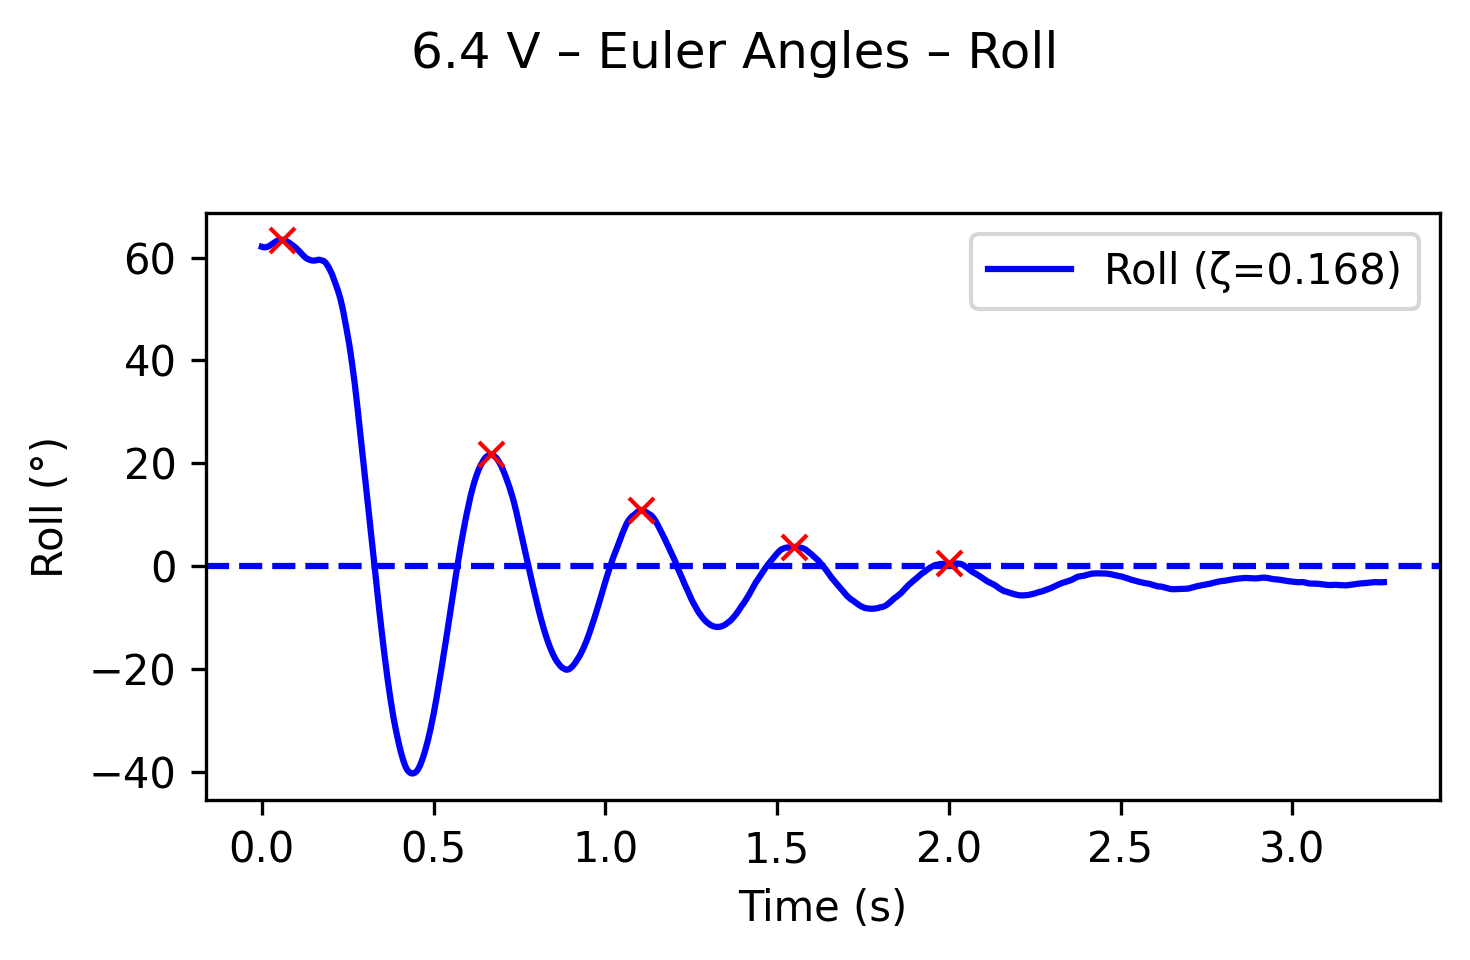

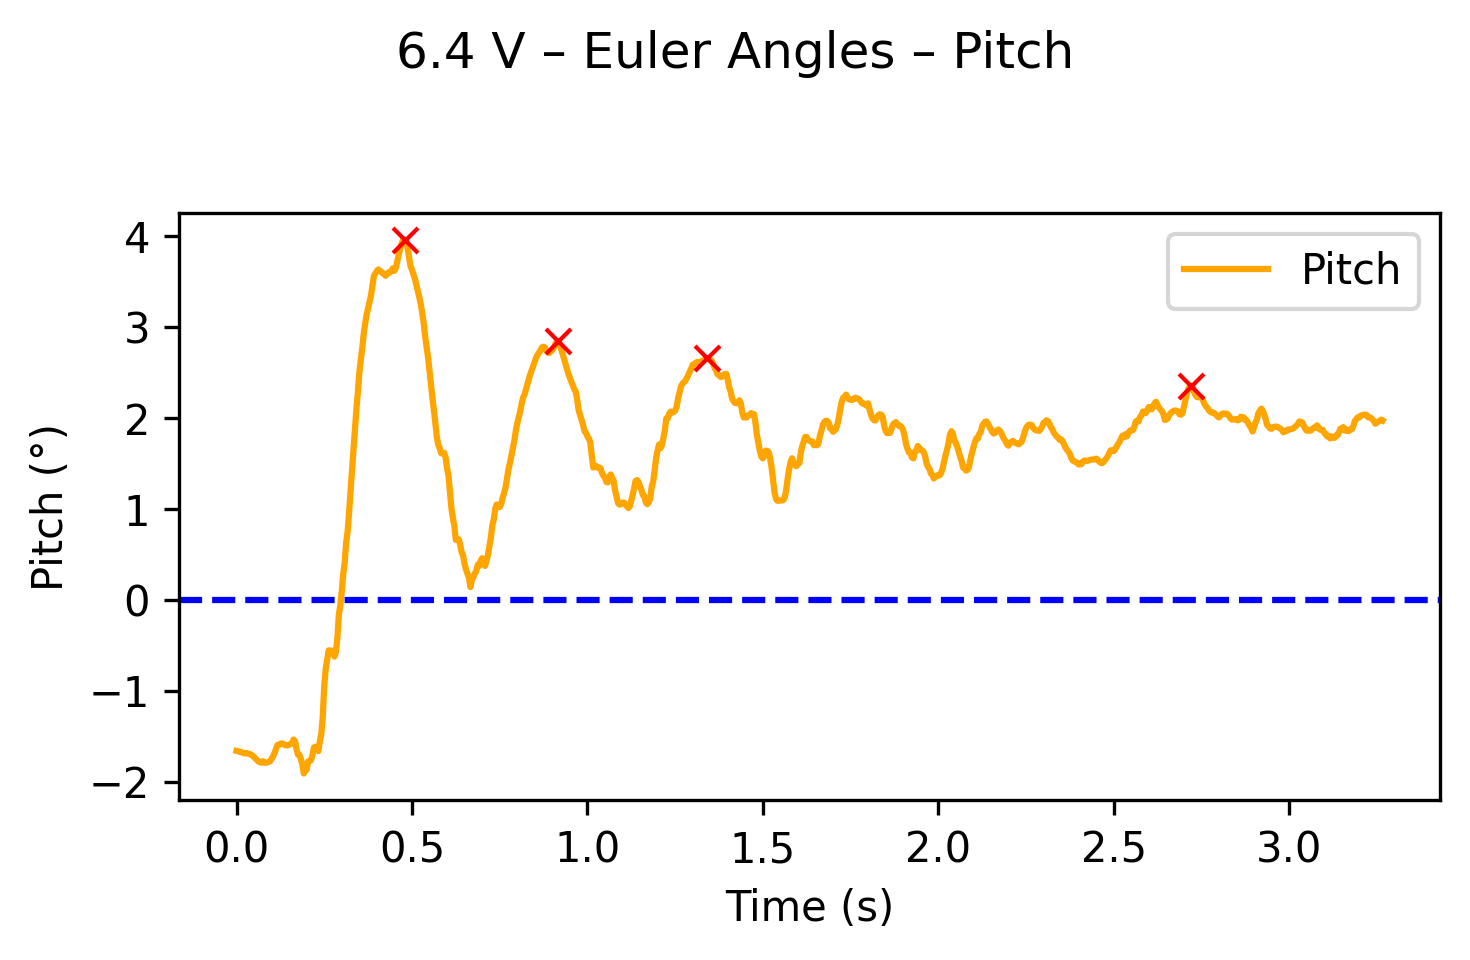

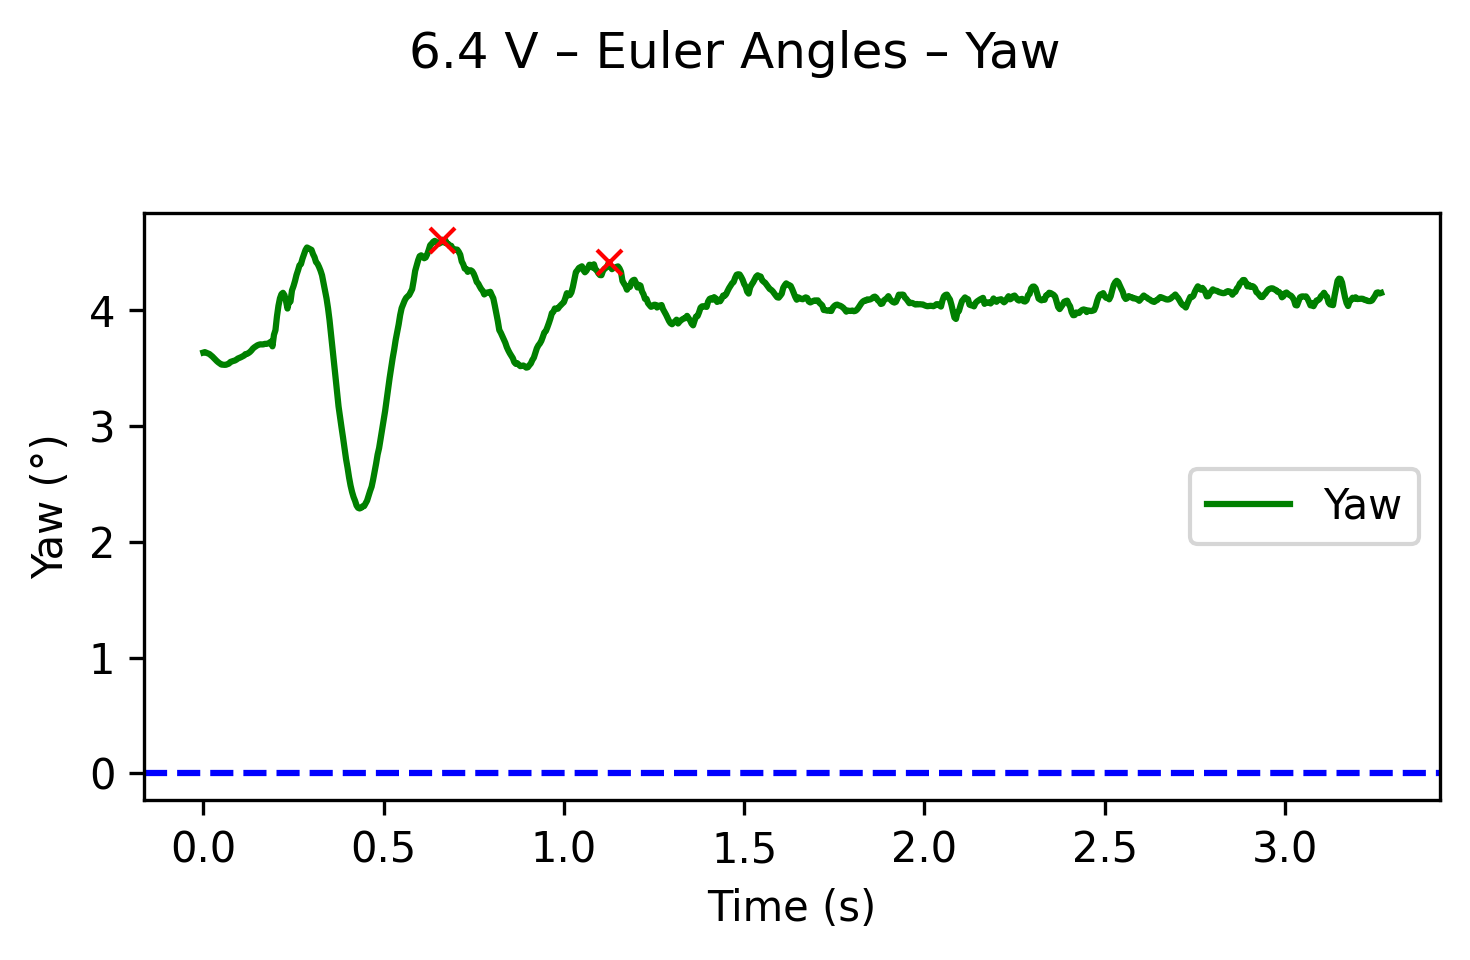

Test @ 1280478417 V — Damping Ratio: 0.168

Average Damping Ratio between tests: 0.168


In [ ]:
# Process and plot Euler angles for each file with peak markers
def process_and_plot_tests(df: pd.DataFrame, voltage: str):
    """
    Processes one test DataFrame, computes damping ratio, and calls the plotter.
    Returns the sum of ratios and count of successful computations.
    """
    total_ratio = 0.0
    count_ratio = 0

    # 1) Compute Euler angles & damping ratio
    euler_df, start_idx, end_idx = process_euler(df)
    ratio, vos = get_damping_ratio(euler_df['Roll'], df['Time'], Gnum=GNUM)

    if ratio is not None:
        total_ratio += ratio
        count_ratio += 1

    # 2) Plot and include damping_ratio in the Roll legend
    figs_axes = plot_euler_angles_with_peaks(
        df,
        euler_df,
        f'6.4 V – Euler Angles',
        start_idx,
        end_idx,
        Gnum=GNUM,
        vos=vos,
        damping_ratio=ratio
    )

    # Add damping ratio to the legend of the Roll plot
    # if ratio is not None:
    #     roll_ax = figs_axes[0][1]  # Get the axes for the Roll plot
    #     handles, labels = roll_ax.get_legend_handles_labels()
    #     labels[0] = f'Roll (Damping Ratio: {ratio:.3f})' # Modify the label for Roll
    #     roll_ax.legend(handles, labels)

    # 3) Print per‐test result
    if ratio is not None:
        print(f'Test @ {voltage} V — Damping Ratio: {ratio:.3f}')
    else:
        print(f'Test @ {voltage} V — Damping Ratio: N/A')
    print()

    return total_ratio, count_ratio



# Run the tests for each voltage
total = 0
count = 0
for sheet_name, df in dataframes.items():
    s,k = process_and_plot_tests(process_dataframe(df), sheet_name)
    total += s
    count += k

print(f'Average Damping Ratio between tests: {total/count:.3f}')

###5v Tests

vertical offset:  -3
peak indices:  [  5 171 304 431 576 722 823]
peak times:  [np.float64(nan), np.float64(0.6875), np.float64(1.241667), np.float64(1.770833), np.float64(2.375), np.float64(2.983333), np.float64(3.404167)]
peak values:  [80.47301193  8.87995542  2.42067244  0.68837052  0.23691378  0.95759572
  1.18733334]


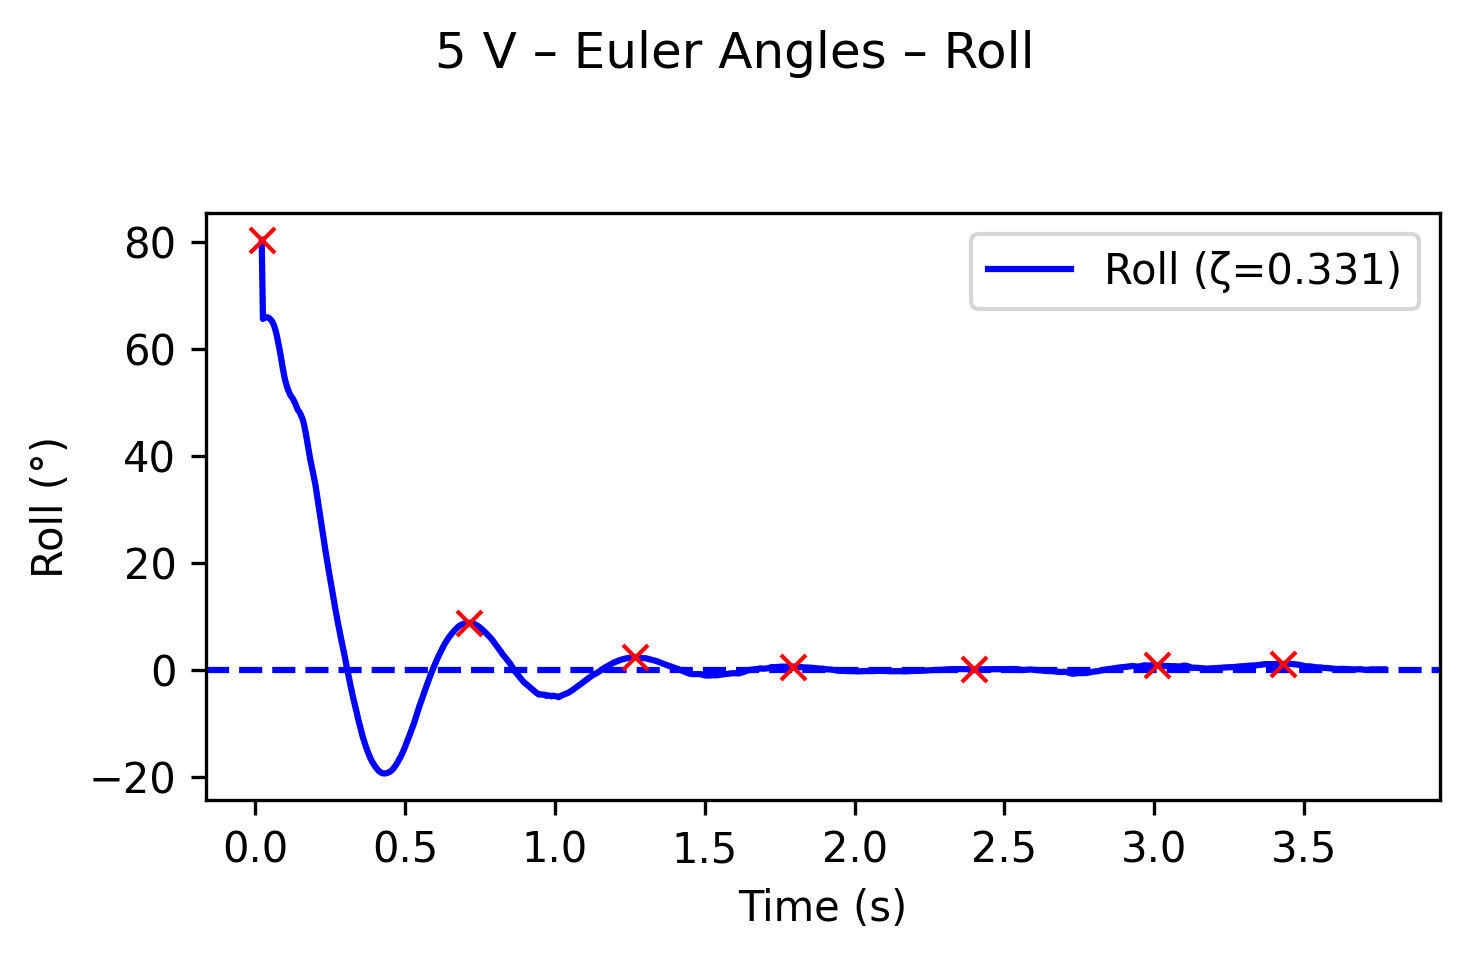

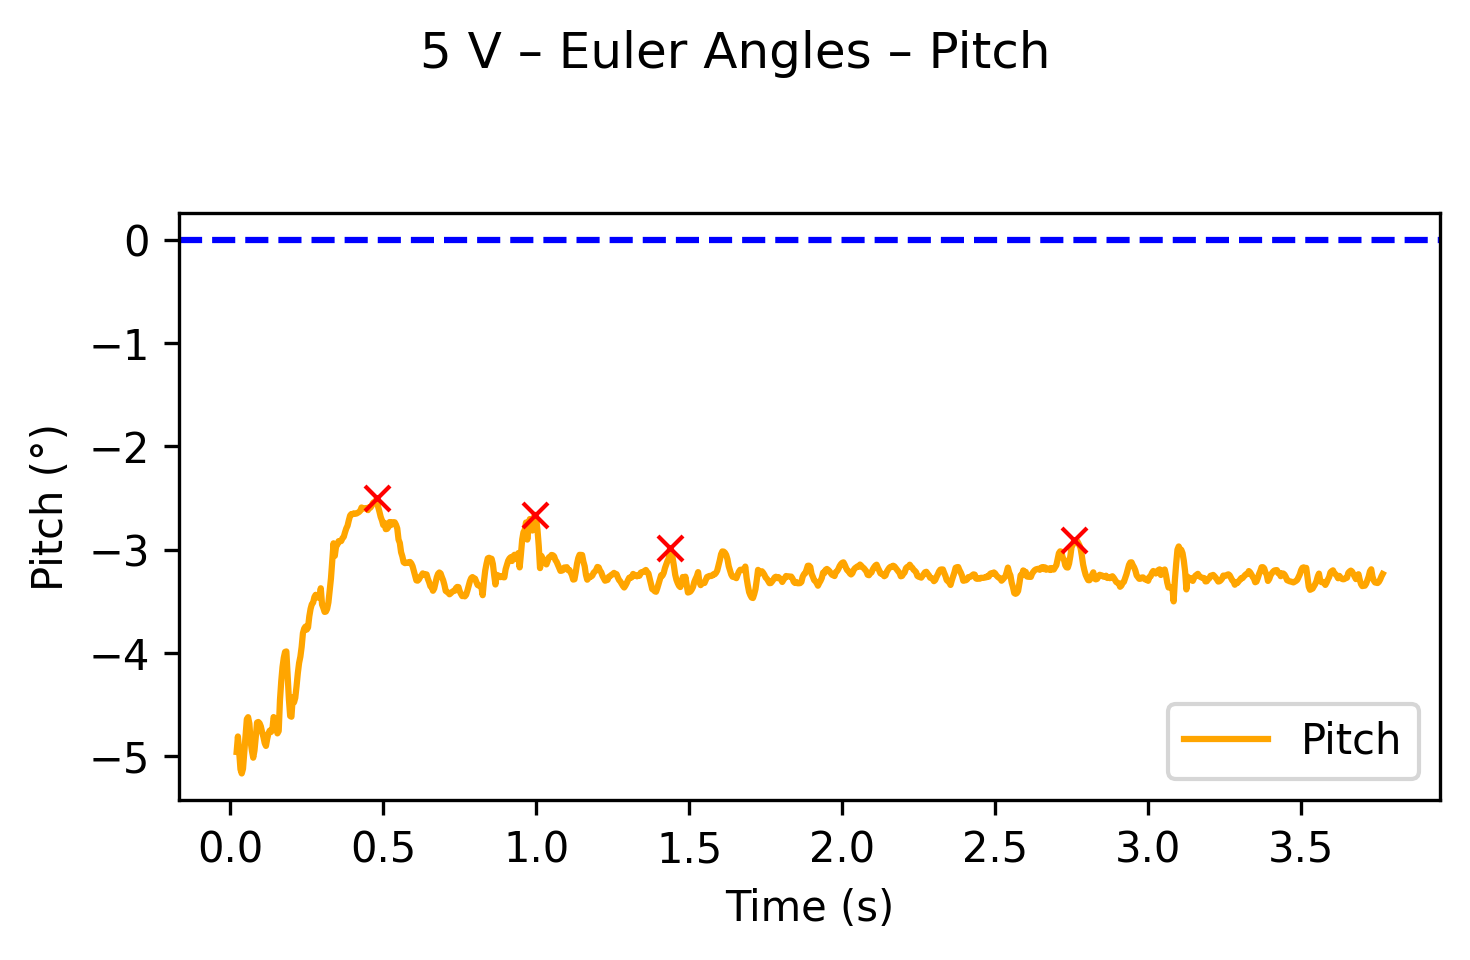

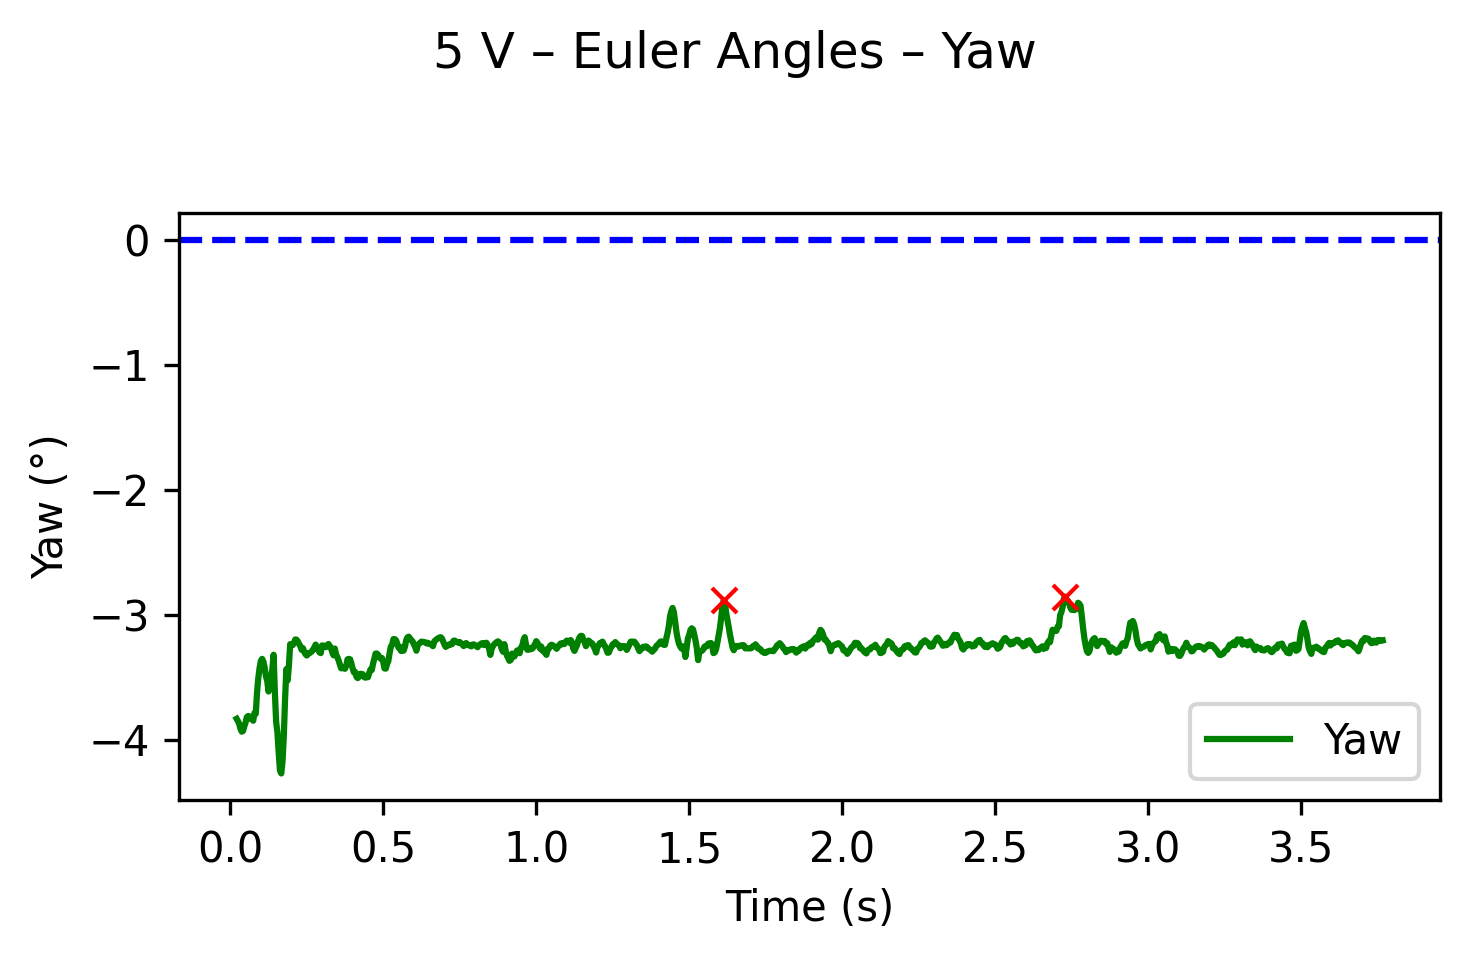

Test @ 128794124 V — Damping Ratio: 0.331

Average Damping Ratio between tests: 0.331


In [ ]:
# Process and plot Euler angles for each file with peak markers
def process_and_plot_tests(df: pd.DataFrame, voltage: str):
    """
    Processes one test DataFrame, computes damping ratio, and calls the plotter.
    Returns the sum of ratios and count of successful computations.
    """
    total_ratio = 0.0
    count_ratio = 0

    # 1) Compute Euler angles & damping ratio
    euler_df, start_idx, end_idx = process_euler(df)
    ratio, vos = get_damping_ratio(euler_df['Roll'], df['Time'], Gnum=GNUM, vertoffset=VERTOFFSET)

    if ratio is not None:
        total_ratio += ratio
        count_ratio += 1

    # 2) Plot and include damping_ratio in the Roll legend
    figs_axes = plot_euler_angles_with_peaks(
        df,
        euler_df,
        f'5 V – Euler Angles',
        start_idx,
        end_idx,
        Gnum=GNUM,
        vos=vos,
        damping_ratio=ratio
    )

    # Add damping ratio to the legend of the Roll plot
    # if ratio is not None:
    #     roll_ax = figs_axes[0][1]  # Get the axes for the Roll plot
    #     handles, labels = roll_ax.get_legend_handles_labels()
    #     labels[0] = f'Roll (Damping Ratio: {ratio:.3f})' # Modify the label for Roll
    #     roll_ax.legend(handles, labels)

    # 3) Print per‐test result
    if ratio is not None:
        print(f'Test @ {voltage} V — Damping Ratio: {ratio:.3f}')
    else:
        print(f'Test @ {voltage} V — Damping Ratio: N/A')
    print()

    return total_ratio, count_ratio


# Run the tests for each voltage
total = 0
count = 0
for sheet_name, df in dataframes.items():
    s,k = process_and_plot_tests(process_dataframe(df), sheet_name)
    total += s
    count += k

print(f'Average Damping Ratio between tests: {total/count:.3f}')

###4v Tests

peaks:  [9.16286393 6.19789581 3.02941147 0.68222871] vertical offset:  0


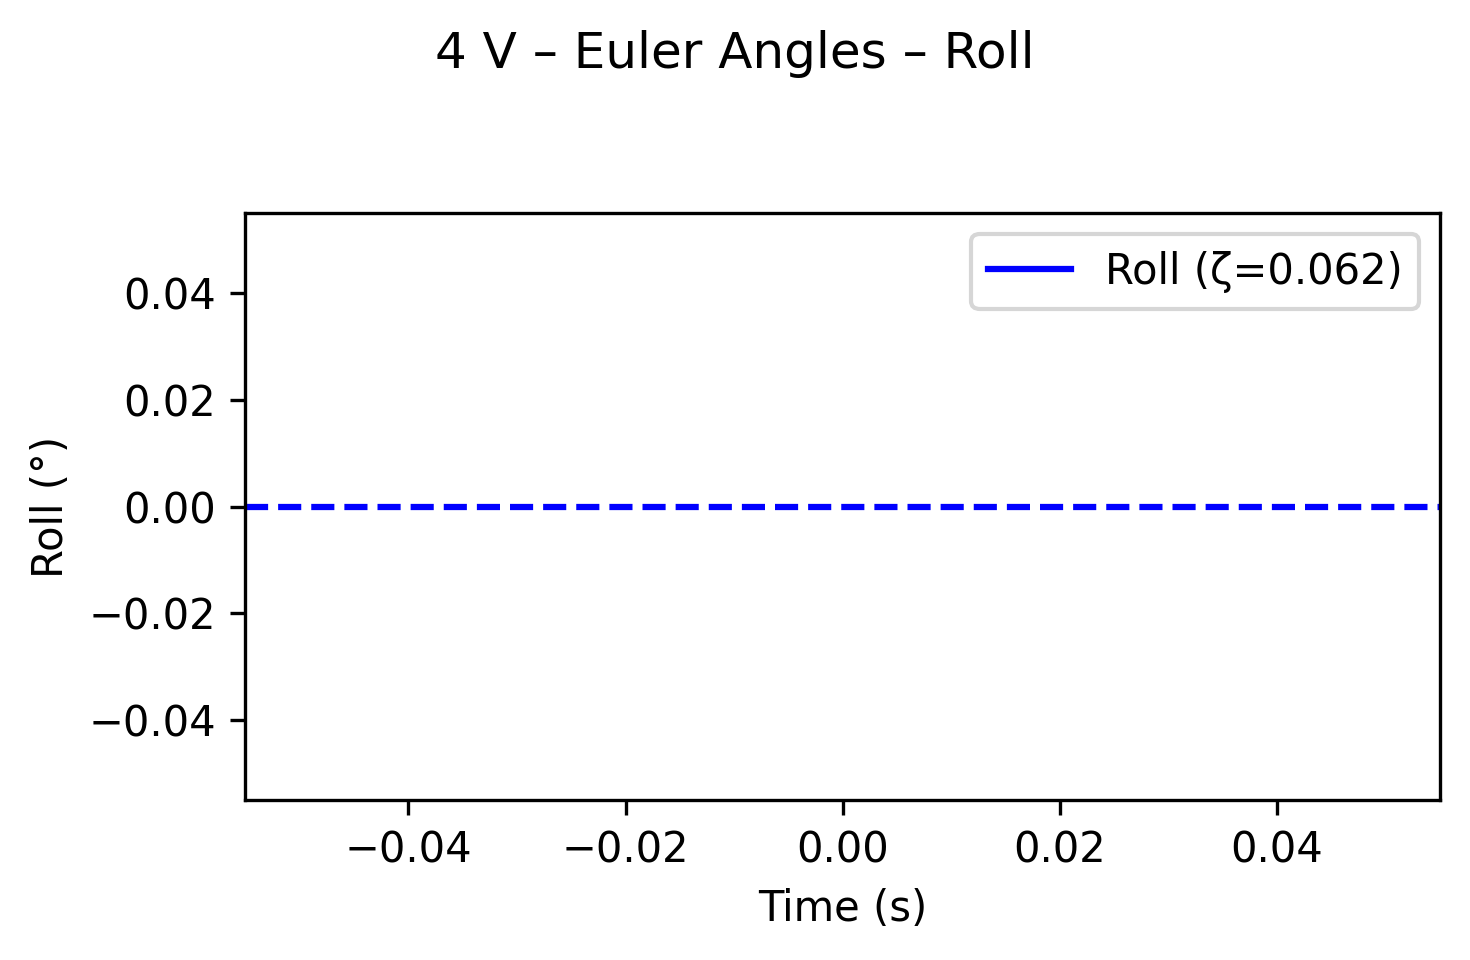

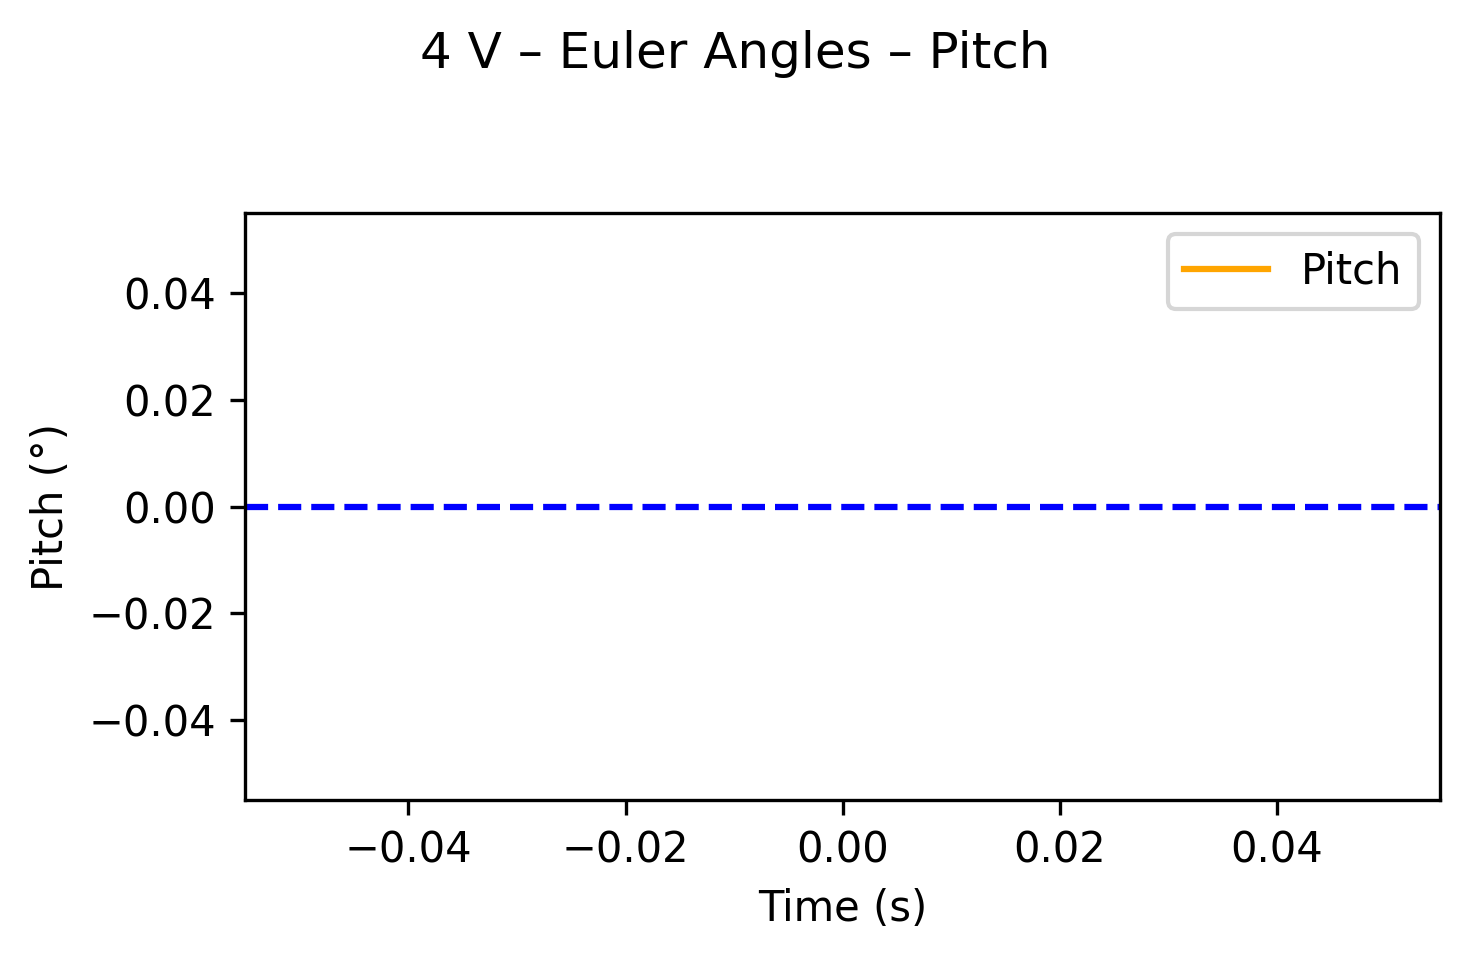

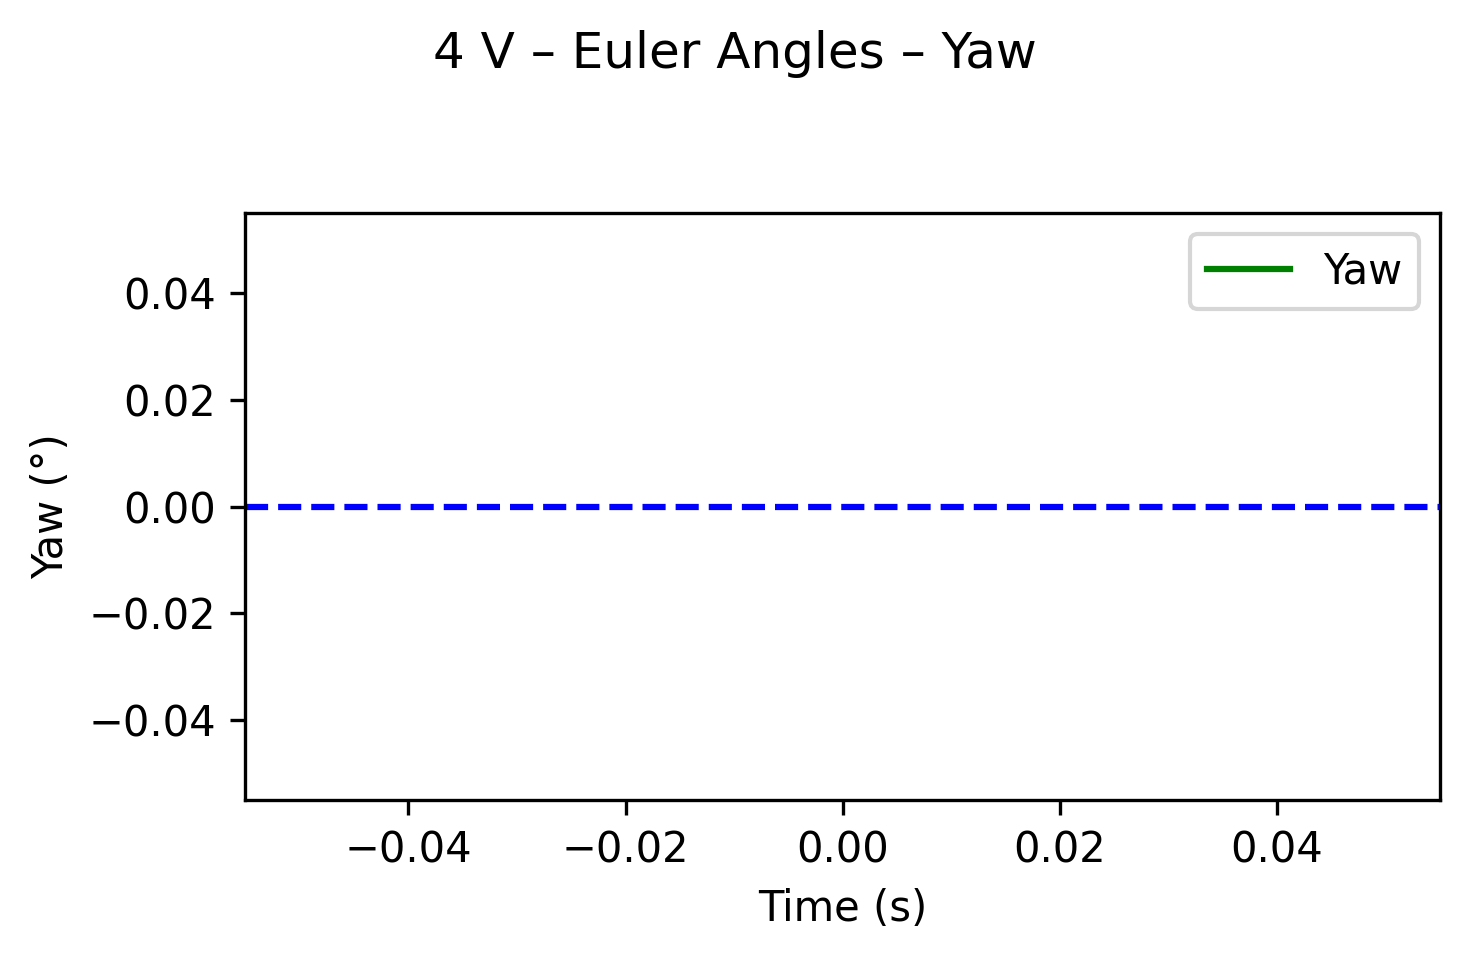

Test @ 955837113 V — Damping Ratio: 0.062

Average Damping Ratio between tests: 0.062


In [ ]:
# Process and plot Euler angles for each file with peak markers
def process_and_plot_tests(df: pd.DataFrame, voltage: str):
    """
    Processes one test DataFrame, computes damping ratio, and calls the plotter.
    Returns the sum of ratios and count of successful computations.
    """
    total_ratio = 0.0
    count_ratio = 0

    # 1) Compute Euler angles & damping ratio
    euler_df, start_idx, end_idx = process_euler(df)
    ratio, vos = get_damping_ratio(euler_df['Roll'], df['Time'], Gnum=GNUM)

    if ratio is not None:
        total_ratio += ratio
        count_ratio += 1

    # 2) Plot and include damping_ratio in the Roll legend
    figs_axes = plot_euler_angles_with_peaks(
        df,
        euler_df,
        f'4 V – Euler Angles',
        start_idx,
        end_idx,
        Gnum=GNUM,
        vos=vos,
        damping_ratio=ratio
    )

    # Add damping ratio to the legend of the Roll plot
    # if ratio is not None:
    #     roll_ax = figs_axes[0][1]  # Get the axes for the Roll plot
    #     handles, labels = roll_ax.get_legend_handles_labels()
    #     labels[0] = f'Roll (Damping Ratio: {ratio:.3f})' # Modify the label for Roll
    #     roll_ax.legend(handles, labels)

    # 3) Print per‐test result
    if ratio is not None:
        print(f'Test @ {voltage} V — Damping Ratio: {ratio:.3f}')
    else:
        print(f'Test @ {voltage} V — Damping Ratio: N/A')
    print()

    return total_ratio, count_ratio



# Run the tests for each voltage
total = 0
count = 0
for sheet_name, df in dataframes.items():
    s,k = process_and_plot_tests(process_dataframe(df), sheet_name)
    total += s
    count += k

print(f'Average Damping Ratio between tests: {total/count:.3f}')

###3v Tests

peaks:  [70.18076718 -0.09131525] vertical offset:  0


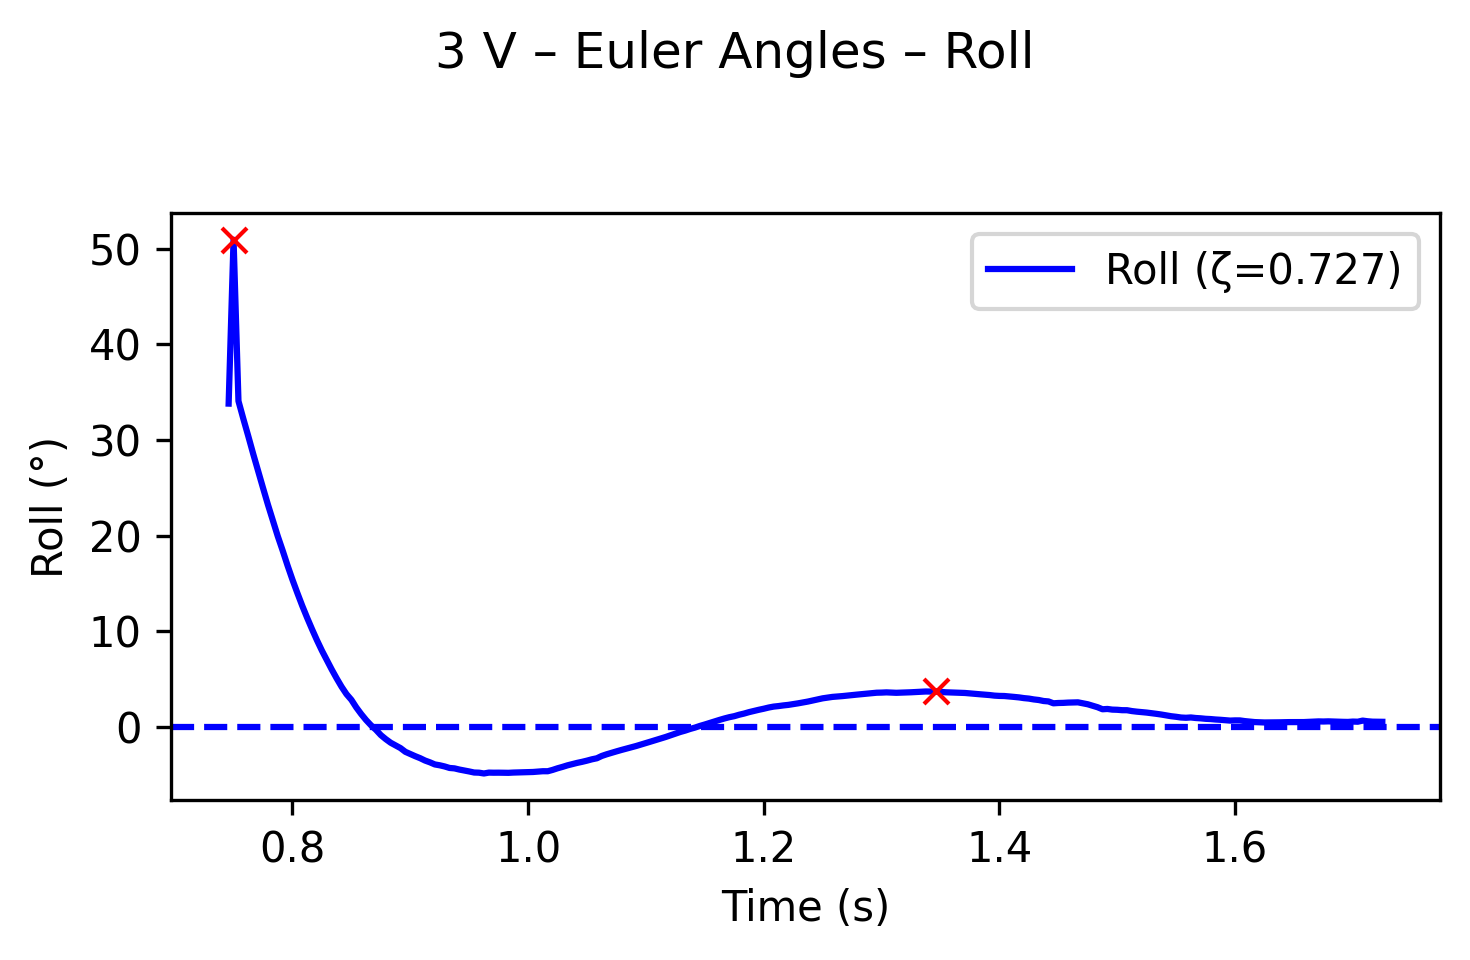

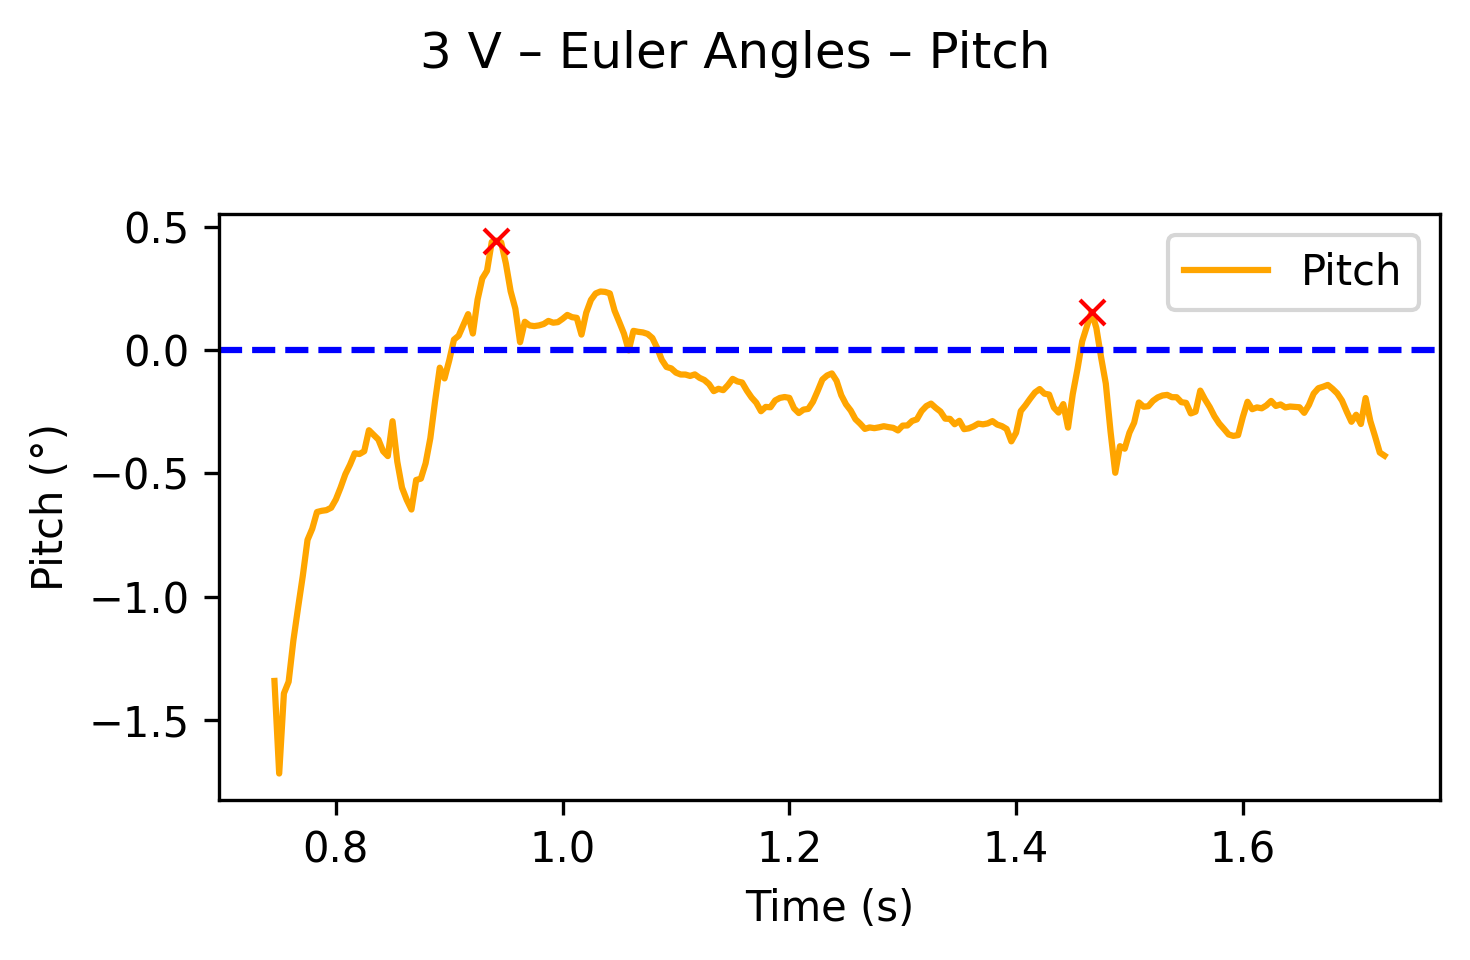

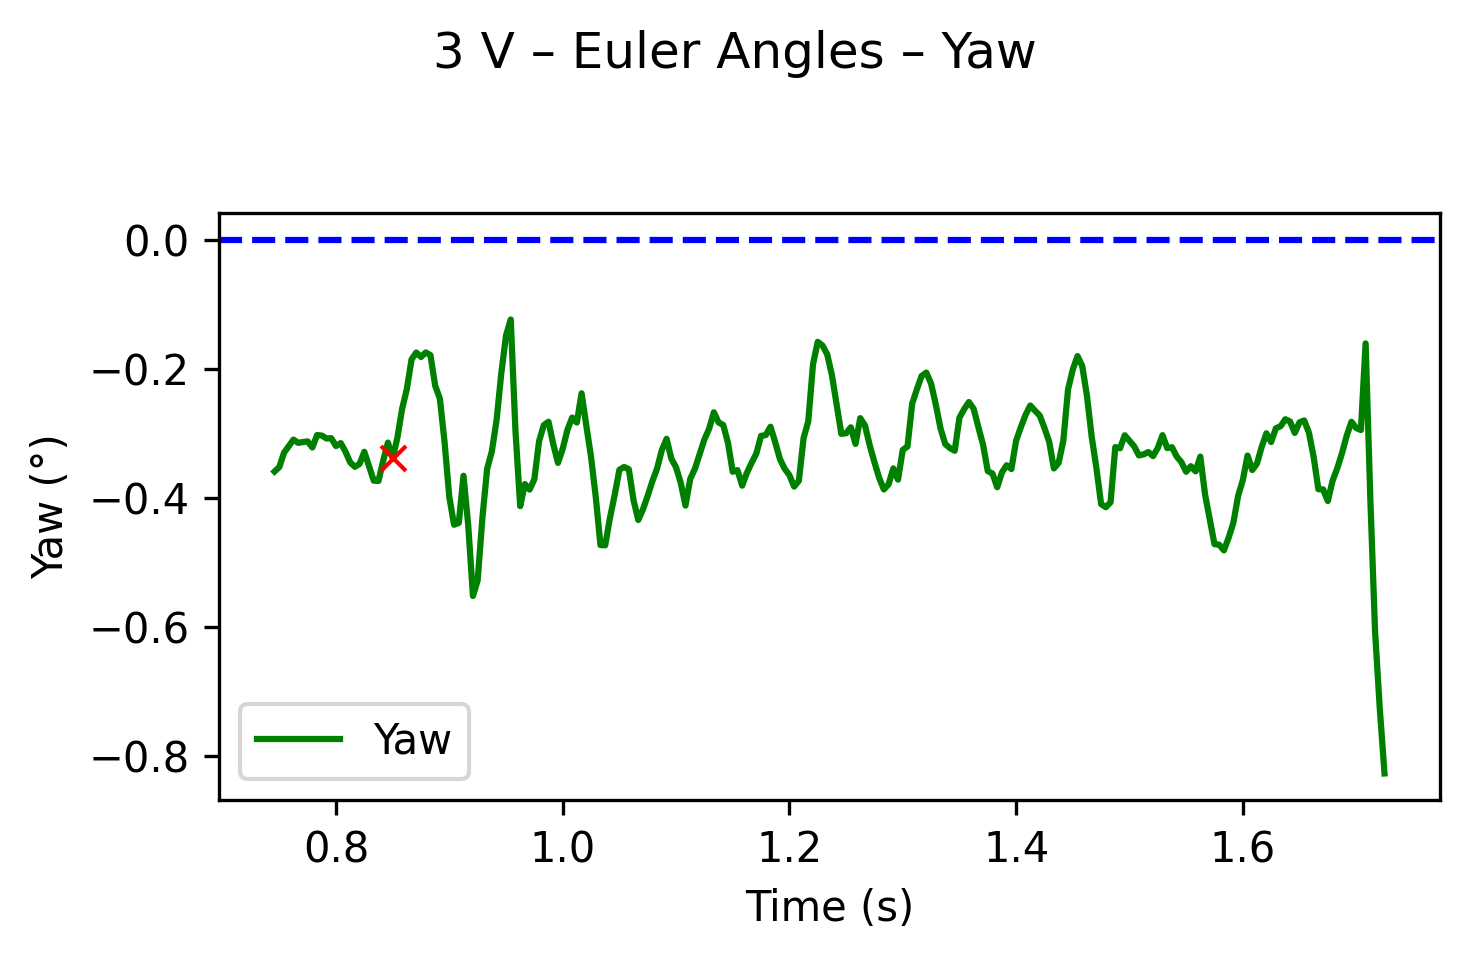

Test @ 512978390 V — Damping Ratio: 0.727

Average Damping Ratio between tests: 0.727


In [ ]:
# Process and plot Euler angles for each file with peak markers
def process_and_plot_tests(df: pd.DataFrame, voltage: str):
    """
    Processes one test DataFrame, computes damping ratio, and calls the plotter.
    Returns the sum of ratios and count of successful computations.
    """
    total_ratio = 0.0
    count_ratio = 0

    # 1) Compute Euler angles & damping ratio
    euler_df, start_idx, end_idx = process_euler(df)
    ratio, vos = get_damping_ratio(euler_df['Roll'], df['Time'], Gnum=GNUM)

    if ratio is not None:
        total_ratio += ratio
        count_ratio += 1

    # 2) Plot and include damping_ratio in the Roll legend
    figs_axes = plot_euler_angles_with_peaks(
        df,
        euler_df,
        f'3 V – Euler Angles',
        start_idx,
        end_idx,
        Gnum=GNUM,
        vos=vos,
        damping_ratio=ratio
    )

    # Add damping ratio to the legend of the Roll plot
    # if ratio is not None:
    #     roll_ax = figs_axes[0][1]  # Get the axes for the Roll plot
    #     handles, labels = roll_ax.get_legend_handles_labels()
    #     labels[0] = f'Roll (Damping Ratio: {ratio:.3f})' # Modify the label for Roll
    #     roll_ax.legend(handles, labels)

    # 3) Print per‐test result
    if ratio is not None:
        print(f'Test @ {voltage} V — Damping Ratio: {ratio:.3f}')
    else:
        print(f'Test @ {voltage} V — Damping Ratio: N/A')
    print()

    return total_ratio, count_ratio



# Run the tests for each voltage
total = 0
count = 0
for sheet_name, df in dataframes.items():
    s,k = process_and_plot_tests(process_dataframe(df), sheet_name)
    total += s
    count += k

print(f'Average Damping Ratio between tests: {total/count:.3f}')

### 2v Tests

peaks:  [64.60660049  1.52969211] vertical offset:  0


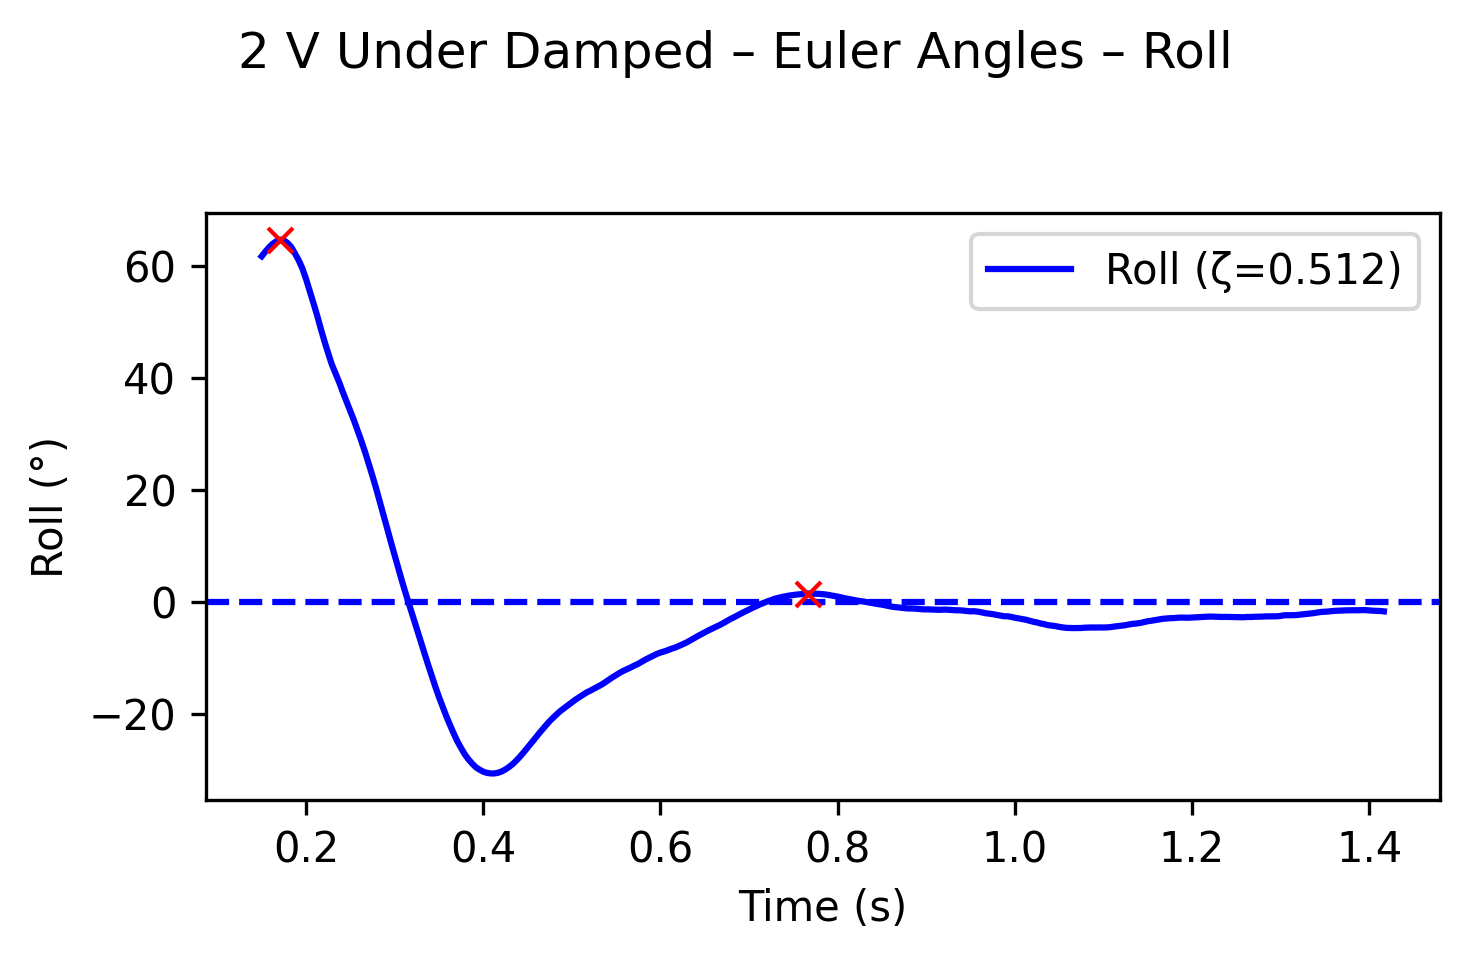

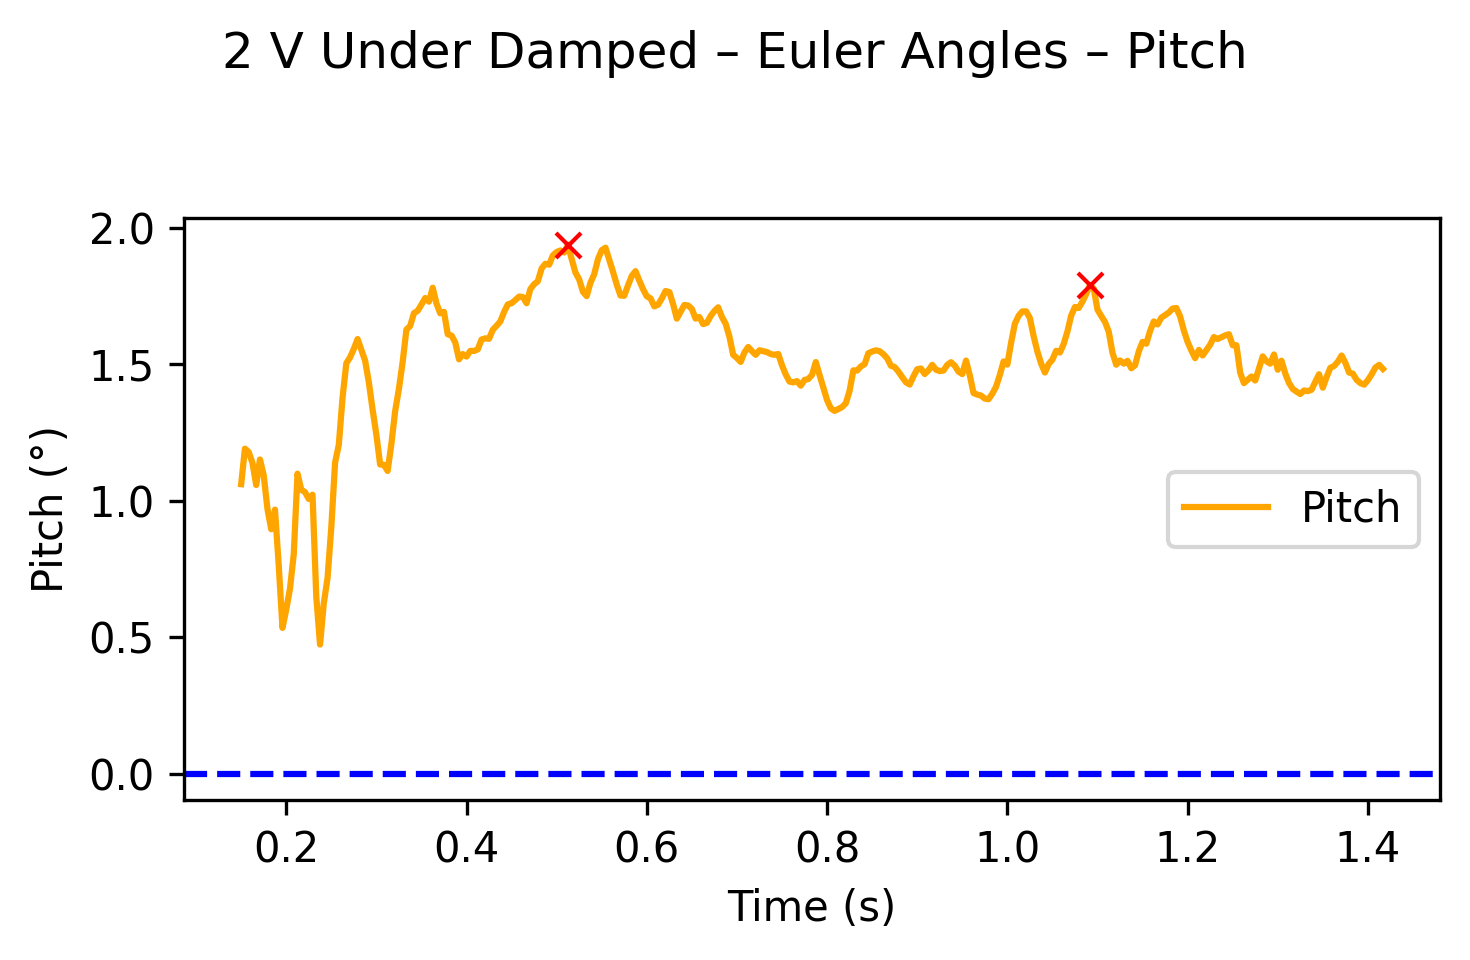

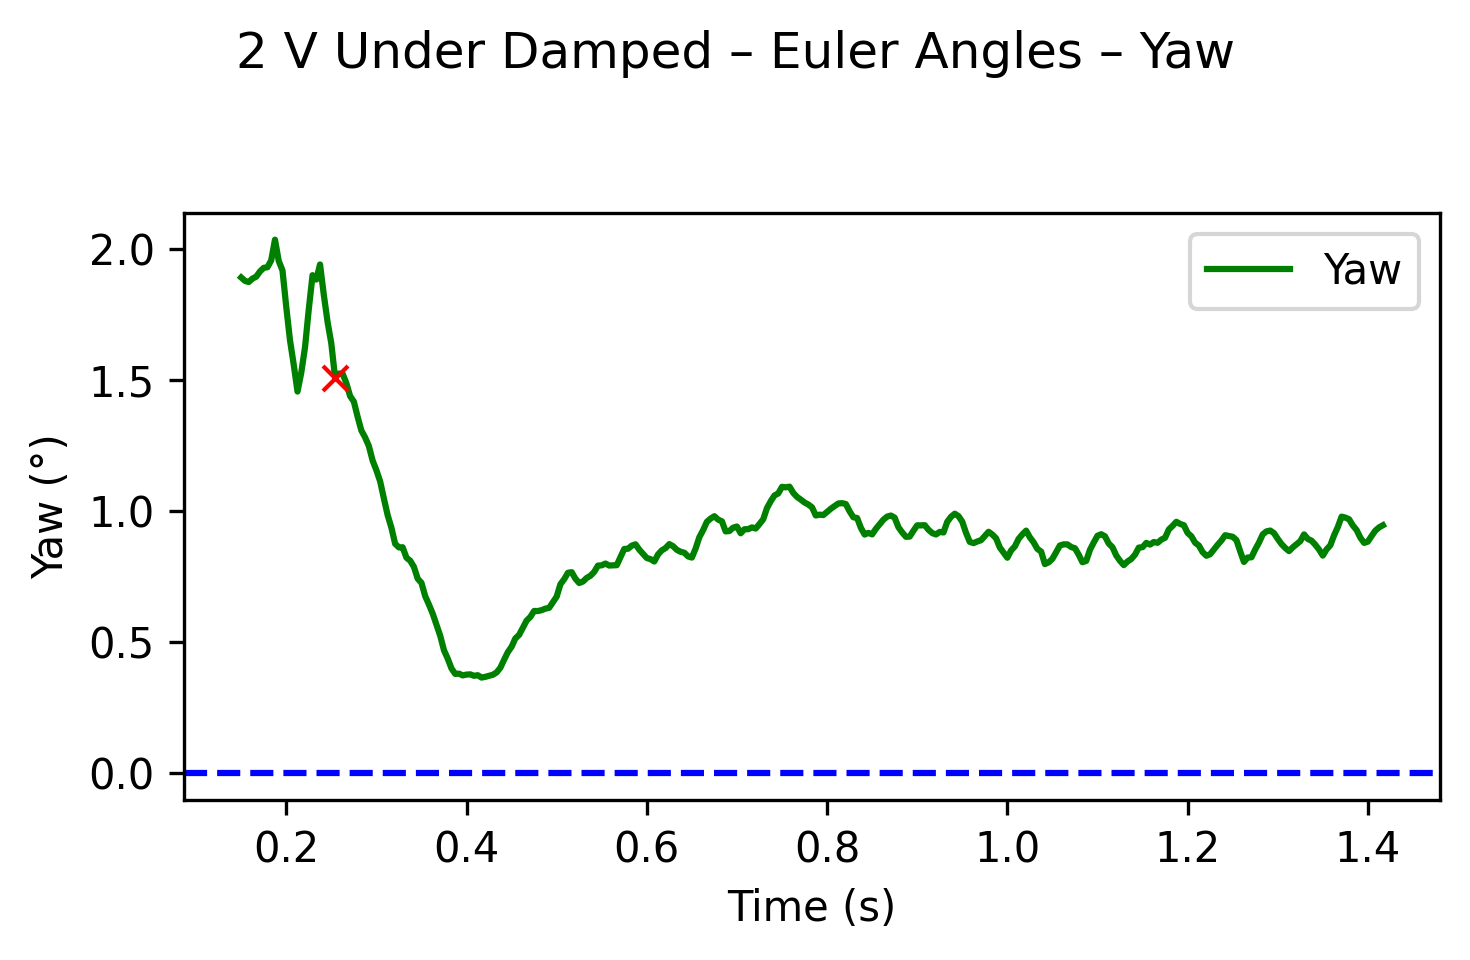

Test @ 1365445703 V — Damping Ratio: 0.512

Average Damping Ratio between tests: 0.512


In [ ]:
# Process and plot Euler angles for each file with peak markers
def process_and_plot_tests(df: pd.DataFrame, voltage: str):
    """
    Processes one test DataFrame, computes damping ratio, and calls the plotter.
    Returns the sum of ratios and count of successful computations.
    """
    total_ratio = 0.0
    count_ratio = 0

    # 1) Compute Euler angles & damping ratio
    euler_df, start_idx, end_idx = process_euler(df)
    ratio, vos = get_damping_ratio(euler_df['Roll'], df['Time'], Gnum=GNUM)

    if ratio is not None:
        total_ratio += ratio
        count_ratio += 1

    # 2) Plot and include damping_ratio in the Roll legend
    figs_axes = plot_euler_angles_with_peaks(
        df,
        euler_df,
        f'2 V Under Damped – Euler Angles',
        start_idx,
        end_idx,
        Gnum=GNUM,
        vos=vos,
        damping_ratio=ratio
    )

    # Add damping ratio to the legend of the Roll plot
    # if ratio is not None:
    #     roll_ax = figs_axes[0][1]  # Get the axes for the Roll plot
    #     handles, labels = roll_ax.get_legend_handles_labels()
    #     labels[0] = f'Roll (Damping Ratio: {ratio:.3f})' # Modify the label for Roll
    #     roll_ax.legend(handles, labels)

    # 3) Print per‐test result
    if ratio is not None:
        print(f'Test @ {voltage} V — Damping Ratio: {ratio:.3f}')
    else:
        print(f'Test @ {voltage} V — Damping Ratio: N/A')
    print()

    return total_ratio, count_ratio



# Run the tests for each voltage
total = 0
count = 0
for sheet_name, df in dataframes.items():
    s,k = process_and_plot_tests(process_dataframe(df), sheet_name)
    total += s
    count += k

print(f'Average Damping Ratio between tests: {total/count:.3f}')